# Potencial Gravitacional de un Disco Protoplanetario

Santiago Andrés Acosta Díaz

La idea de este ejercicio es resolver la PDE 

$$
    \frac{\partial^2 \Phi}{\partial r^2} + \frac{1}{r} \frac{\partial \Phi}{\partial r} + \frac{\partial^2 \Phi}{\partial z^2} = 4 \pi G \rho(r, z) 
$$

con

$$
    \rho(r, z) = \rho_0 e^{-\frac{r}{r_0}} e^{-\frac{z^2}{2h^2}}
$$

donde 

$$
    \rho_0 = 10^{-9} \,g \, cm^{-3}, \qquad h = 0.5 \,UA \qquad r_0 = 3 \, UA
$$

y condiciones de Dirichlet $\Phi = 0$ en los bordes $R_{max} = 10 \, UA$ y $Z_{max} = 2 \, UA$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
#    CONSTANTES
# -----------------------------

rho0 = 10**(-9)
hc = 0.5
r0 = 3.0

Rmax = 10.0
Zmax = 2.0

Nr = 50
Nz = 20

G = 6.674e-8    # G pero en g y cm para que tenga las mismas unidades que rho_0

RHSconstant = 4. * np.pi * G
rExpConstant = -1./(r0)   # Constante dentro de la exp de r
zExpConstant = -1./(2. * hc**2)   # Constante dentro de la exp de z

# -----------------------------
#    OTRAS DEFINICIONES
# -----------------------------

def RHS(r, z):
    """ Lado derecho de la ecuación de Poisson"""
    return RHSconstant * np.exp(-r/r0) * np.exp(rExpConstant * r) * np.exp(zExpConstant * z**2)

## Discretización

Lo primero es discretizar la PDE. El primer problema es saber si tenemos que hacer algo especial por estar usando cilíndricas, sin embargo, para el método que estamos usando y sobre todo, considerando que estamos trabajando las coordenadas naturalmente cartesianas (no involucramos el ángulo azimutal), entonces podemos discretizar por diferencias finitas como siempre lo hemos hecho.

Considerando que 

$$
    \frac{\partial^2 f}{\partial x^2} \approx \frac{f_{i-1} - 2f_{i} + f_{i+1}}{\Delta x^2}
$$

y que 

$$
    \frac{\partial f}{\partial x} \approx \frac{f_{i+1} - f_{i-1}}{2 \Delta x},
$$

reemplazando en la ecuación, y suponiendo que en efecto espaciamos el plano r-z igualmente ($\Delta r = \Delta z = h$), podemos llegar a que 

$$
    \frac{1}{h^2} \left( \Phi_{i-1, j} + \Phi_{i+ 1, j} + \Phi_{i, j-1} + \Phi_{i, j+1} - 4\Phi_{i, j} \right) + \frac{1}{2 r_i h} \left( \Phi_{i+1, j} - \Phi_{i-1, j} \right) = RHS
$$

con $RHS = 2 \pi G \rho(r, z)$.


__CONSIDERACIÓN:__ puede que el primer término en $r = 0$ sea problemática por el $1/r$ , sin embargo, nosotros evitamos tocar este bien porque las condiciones de frontera nos establecen que $\Phi$ en los bordes es $0$. 

## Gauss-Seidel

Básicamente, tenemos que despejar los términos $\Phi_{i, j}$ y a partir de ellos, vamos a tener nuestra nueva regla de iteración.

$$
    \Phi_{i, j}^{(new)} = \frac{1}{4} \left[ \Phi_{i-1, j} + \Phi_{i+1, j} + \Phi_{i, j-1} + \Phi_{i, j+1} + \frac{h}{2r_i} \left( \Phi_{i+1, j} - \Phi_{i-1, j} \right) - h^2 RHS \right]
$$

In [2]:
def Gauss_Seidel(r, z, PHI, lamb = 0.0):
    """ Función que toma la mesh en un instante dado de tiempo y actualiza con Gauss-Seidel puro"""

    # obtenemos los shapes para hacer las iteraciones
    Rshape = r.shape[0]
    Zshape = z.shape[0]

    # Como las condiciones de frontera me dejan en 0.0 todos los bordes, iteramos en el interior
    for i in range(1, Rshape - 1):
        for j in range(1, Zshape - 1):

            PHI[i, j] = 0.25 * ( PHI[i-1, j] + PHI[i+1, j] + PHI[i, j-1] + PHI[i, j+1] 
                                 + (hc / (2. * r[i]) )*( PHI[i+1, j] - PHI[i-1, j] ) - hc**2 * RHS(r[i], z[j]) )

    return PHI


def evol_Gauss_Seidel(r, z, PHI, evol_algorithm = Gauss_Seidel, eps = 0.1, lamb = 1.5):
    """ Esta función evoluciona el sistema hasta que converja por Gauss_Speil """

    def calculate_eps(PHI_old, PHI_new):
        """ Cálculo del error en una iteración """
        PHI_new_safe = np.where(PHI_new == 0, 1e-10, PHI_new)  # To avoid division by 0.0
        return np.max(100.0 * np.abs( (PHI_new - PHI_old) / PHI_new_safe ))

    iter_count = 1  # Guardamos el número de iteraciones por el momento
    
    # Guardamos el PHI viejo
    PHI_prev = PHI.copy()

    # Damos un paso
    PHI = evol_algorithm(r, z, PHI, lamb = lamb)

    # Calculamos el primer error
    error = calculate_eps(PHI_prev, PHI)

    # Revisamos convergencia
    while error > eps:

        # Guardamos y evolucionamos
        PHI_prev = PHI.copy()
        PHI = evol_algorithm(r, z, PHI, lamb = lamb)

        # Calculamos el error
        error = calculate_eps(PHI_prev, PHI)
        iter_count += 1       # Aumentamos contados

    print(f"Convergencia en {iter_count} iteraciones con un error={error}%")
    return PHI
        
    
    

## SOR

Ahora, para implementar el método SOR, lo que tenemos que hacer es prácticamente los mismos pasos de evolución de Gauss-Speil, pero agregando el paso intermedio

$$
    \Phi_{i, j}^{relajado} = \lambda \Phi_{i, j}^{nuevo} + (1 - \lambda) \Phi_{i, j}^{viejo}
$$

__NOTA:__ _en este caso, no creo un algoritmo de evolución propio para este método, sólo le voy a pasar como argumento al algoritmo anterior el método a creal en vez del Gauss_Seidel._ 

In [3]:
def SOR(r, z, PHI, lamb = 1.5):
    """ Función que toma la mesh en un instante dado de tiempo y actualiza con Gauss-Seidel puro"""

    # Obtenemos los shapes para hacer las iteraciones
    Rshape = r.shape[0]
    Zshape = z.shape[0]

    # Como las condiciones de frontera me dejan en 0.0 todos los bordes, iteramos en el interior
    for i in range(1, Rshape - 1):
        for j in range(1, Zshape - 1):

            # Guardamos la entrada
            PHI_viejo = PHI[i, j]

            # Evolucionamos como Gauss_Speil
            PHI_nuevo = 0.25 * ( PHI[i-1, j] + PHI[i+1, j] + PHI[i, j-1] + PHI[i, j+1] 
                                 + (hc / (2. * r[i]) )*( PHI[i+1, j] - PHI[i-1, j] ) - hc**2 * RHS(r[i], z[j]) )
            
            # Creamos la nueva entrada relajada
            PHI[i, j] = lamb*PHI_nuevo + (1. - lamb)*PHI_viejo
            
    return PHI

## Creación de gráficas

La tarea nos pide graficar el heatmap y curvas equipotenciales para ambos métodos.

In [4]:
def create_plots(F, x, y, nx = 6, ny = 5, method = "Gauss-Seidel", Fg = False):
    # Para que se vea bonito, primero formateo los x e y
    formatted_x = [f"{xi:.2f}" for xi in x]
    formatted_y = [f"{yi:.2f}" for yi in y]

    # Determinar los labels a poner
    num_labels_x = min(nx, len(formatted_x))
    x_indices = np.linspace(0, len(x) - 1, num_labels_x).astype(int)

    num_labels_y = min(ny, len(formatted_y))  # Corrected this line to use ny instead of nx
    y_indices = np.linspace(0, len(y) - 1, num_labels_y).astype(int)

    # Creamos el heatmap 
    fig, ax = plt.subplots()

    im = ax.imshow(F.T, cmap='viridis')

    

    if Fg:
        ax.set_title(r'Fuerza gravitacional radial')
        
        # Añadimos un colorbar
        cbar = fig.colorbar(im, ax = ax, label = r"$\ln(F_r)$ [U. Arbitrarias]", orientation = "horizontal")
    else:
        ax.set_title(f'Heatmap usando {method}')
        cbar = fig.colorbar(im, ax = ax, label = r"$\Phi$ [U. Arbitrarias]", orientation = "horizontal")

    ax.set_xlabel('r [U.A]')
    ax.set_ylabel('z [U.A]')
        
    # Ponemos los ejes correctamente
    ax.set_xticks(x_indices)
    ax.set_yticks(y_indices)
    ax.set_xticklabels([formatted_x[i] for i in x_indices])
    ax.set_yticklabels([formatted_y[i] for i in y_indices])

    # Graficamos las líneas de contorno
    if not Fg:
        contours = ax.contour(F.T, levels=5, colors='black')

    plt.show()

## Fuerza gravitacional

También nos pide calcular la $F_G$ radial

$$
    F_r = -\frac{\partial \Phi}{\partial r}
$$

y discutir si el perfil es el deseado para un disco kleperiano. Para esto, vamos simplemente a usar `np.gradient(PHI, axis = 0)`, y revisaremos las conclusiones después.

Importante considerar que estamos en coordenadas cilíndricas, entonces estoy hablando del $r$ cilíndrico. 

## Comparar con resultado analítico

Se nos pide comparar este resultado con

$$
    \Phi = -\frac{GM}{\sqrt{r^2 + z^2}}
$$

In [5]:
def anal_solution(r, z):
    return -(G*M) / (np.sqrt(r**2 + z**2))

# Conclusiones

Lo primero es ver cómo corren ambos métodos y cuántas iteraciones tardan

In [6]:
# Creamos el mesh
r = np.linspace(0, Rmax, Nr)
z = np.linspace(-Zmax, Zmax, Nz)   # Como estamos en cilíndricas, esperamos que sea simétrico en el eje z

# Inicializamos una matrix que represente \Phi
PHI = np.zeros([Nr, Nz])

# Evolucionamos por GS
PHI_GS = evol_Gauss_Seidel(r, z, PHI.copy(), evol_algorithm=Gauss_Seidel)
PHI_SOR = evol_Gauss_Seidel(r, z, PHI.copy(), evol_algorithm=SOR, lamb = 1.5)

Convergencia en 220 iteraciones con un error=0.09903896736314%
Convergencia en 93 iteraciones con un error=0.09988958802112802%


viendo que, primeramente, el método __SOR__ converge poco más del doble de rápido con $\lambda = 1.5$, viendo entonces que este método, que apenas y agrega un paso extra a Gauss-Speil, mejora considerablemente la eficacia del sistema.


Ahora, se nos pide graficar estos resultados

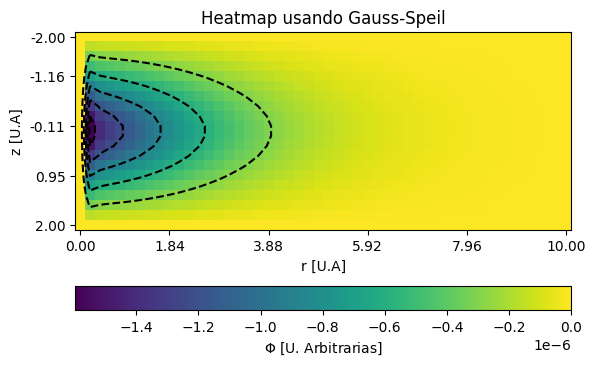

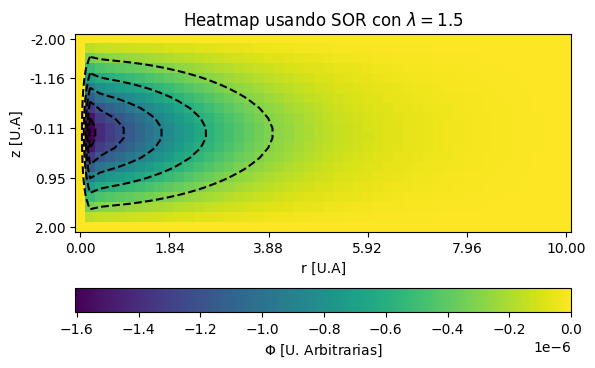

In [7]:
create_plots(PHI_GS, r, z, method = "Gauss-Speil")
create_plots(PHI_SOR, r, z, method = "SOR con $\lambda = 1.5$")

Las anteriores gráficas, aparte de ser bonitas, nos muestran una física correcta:

* La gran parte de la densidad se encuentra en el disco protoplanetario $r < r_0 = 3 \,[U.A.]$ y $|z| < h = 0.5 \, [U.A.]$, donde a priori se encuentra concentrada la masa del disco.
* El potencial gravitatorio, al tener una mayor extensión, se "difunde" sobre estos límites y cae rápidamente, como es de esperarse.


Ahora, para calcular la fuerza gravitacional, vamos a usar el $\Phi$ hallado por SOR y vamos a utilizar la función ya implementada de numpy para esto.

/tmp/ipykernel_143239/1263726135.py:1: RuntimeWarning: divide by zero encountered in log
  F_r = np.log(np.gradient(PHI_SOR, axis = 0))
/tmp/ipykernel_143239/1263726135.py:1: RuntimeWarning: invalid value encountered in log
  F_r = np.log(np.gradient(PHI_SOR, axis = 0))


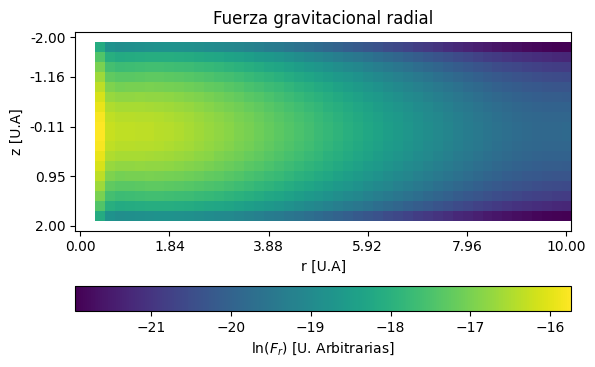

In [8]:
F_r = np.log(np.gradient(PHI_SOR, axis = 0))

create_plots(F_r, r, z, Fg=True)

Aquí, podemos ver un comportamiento adecuado (notar que el eje $z$ está invertido):

1. A medida que nos alejamos en $r$, la fuerza decrese
2. Igualmente, se decrese al aumentar en $|z|$
3. Estamos graficando el logaritmo del gradiente, entonces los signos negativos sólo nos indican la escala $<1$ del campo dadas las unidades que escogimos, pero a medida que nos alejamos, efecticamente, el campo se reduce al aumentar los valores negativos del logaritmo.
4. Los bordes pueden contener artefactos de las condiciones de frontera que le inyectamos al sistema.

Esto anterior nos indica que el modelo que usamos, a pesar de tener problemas en las fronteras, genera una situación física real.


Finalmente, vamos a comparar con el resultado analítico.

Masa puntual aproximada 46.747404693396646


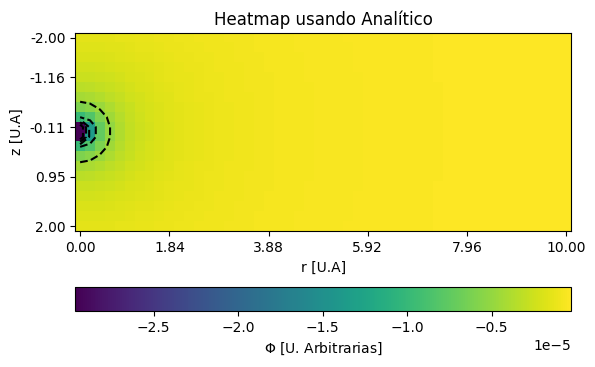

Potencial total en masa puntual 0.001052710009468205
Potencial total en disco 0.00019256530830235759


In [24]:
# Creamos la meshgrid 
R, Z = np.meshgrid(r, z)

# Voy a tener una aproximación de la masa puntual "integrando"
M = np.sum(RHS(R, Z) / RHSconstant)
print(f"Masa puntual aproximada {M}")

PHI_anal = anal_solution(R, Z)

create_plots(PHI_anal.T, r, z, method = "Analítico")


print(f"Potencial total en masa puntual {np.sum(abs(PHI_anal))}")
print(f"Potencial total en disco {np.sum(abs(PHI_SOR))}")

Podemos ver que, primero, podemos medianamente recuperar la escala de $\Phi$ al usar la masa integrada de $\rho$ sobre todo el espacio como la masa puntual. Sin embargo, la forma y la extensión son completamente diferentes en este caso, concentrado la masa puntual casi que toda la densidad de potencial alrededor del origen, mientras que el modelo del disco protoplanetario es mucho más extenso y realista. 

Sin embargo, ambos modelos no son capaces de recrear el mismo potencial total en el espacio, 